In [2]:
# pip install segmentation_models_pytorch

In [3]:
# pip install git+https://github.com/qubvel/segmentation_models.pytorch

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import pydicom as dicom

In [5]:
import segmentation_models_pytorch as smp
model = smp.Unet(
    encoder_name="resnet34",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=2,                      # model output channels (number of classes in your dataset)
)

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /tmp/xdg-cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


  0%|          | 0.00/83.3M [00:00<?, ?B/s]

In [6]:
from segmentation_models_pytorch.encoders import get_preprocessing_fn

preprocess_input = get_preprocessing_fn('resnet34', pretrained='imagenet')

In [7]:
preprocess_input

functools.partial(<function preprocess_input at 0x7f588b8808b0>, input_space='RGB', input_range=[0, 1], mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [35]:
img_with_label = pd.read_csv('Pneumothorax_reports.csv')
img_with_label

,filename,SOPInstanceUID,StudyInstanceUID,EncodedPixels,Report
0,P0_04_11_2563_DICOM_00003CE3_AA5E0983_AAABDF17...,0.6.16.756977.42.5.5.0.84319505740.37071111735...,2.1.626.26.9.3585233689.039662,-1,"Clinical data: Central chest pain, hypertensio..."
1,P1_04_11_2563_DICOM_00007C47_AAF286F4_AAD441BF...,0.2.95.898927.84.7.3.8.93105928782.85706656872...,4.4.086.96.6.0546511087.981344,-1,\nClinical data: Chest pain.; \n \nMedical q...
2,P2_04_11_2563_DICOM_000092B9_AA9D0BC8_AA3EE075...,9.2.34.674100.41.6.9.5.92304504941.79045650880...,2.4.593.91.1.1571289800.033197,-1,\nClinical data: Exacerbation of asthma. Inj...
3,P3_04_11_2563_DICOM_0000E7C7_AA1E8FE9_AAC4FD4C...,5.3.65.845056.28.5.1.1.90697381865.17178541020...,6.1.286.66.1.9891404968.608733,-1,"\nClinical data: Headache, nausea and vomitin..."
4,P4_05_12_2563_DICOM_00004417_AAD0D8C4_AAD9F44D...,6.0.64.094906.85.9.9.7.14812998323.13442290893...,0.7.767.77.4.8479467637.238283,-1,\nClinical data: Pre operative.; \n \nMedica...
...,...,...,...,...,...
19635,P13741_01_04_2573_DICOM_00008271_AAC28144_AA82...,2.4.32.065800.28.8.5.8.96235857176284.83556086...,3.5.84.276161.20.29.9.6.25829.85540.30212.4903...,182592 5 1017 6 1015 7 1014 8 1014 9 1012 10 1...,Chest X-Ray [DATE]\n\n\n[PERSONALNAME]\n\n[PE...
19636,P12478_01_02_2573_DICOM_00006761_AAF8D7A3_AA88...,9.5.27.390211.64.6.7.4.25012056138979.85608719...,5.3.784.93.1.130184217.4420308,199319 8 1001 38 982 44 973 54 964 64 956 72 9...,Chest X-Ray [DATE]:[DATE]\n\nCLINICAL DETAILS...
19637,P12478_01_02_2573_DICOM_00006761_AAF8D7A3_AA88...,9.5.27.390211.64.6.7.4.25012056138979.85608719...,5.3.784.93.1.130184217.4420308,229669 75 923 105 911 116 899 125 893 126 894 ...,Chest X-Ray [DATE]:[DATE]\n\nCLINICAL DETAILS...
19638,P13745_03_04_2573_DICOM_0000B0F7_AA69AC7D_AAE8...,4.1.60.275960.48.0.4.4.48132913230334.38951715...,3.7.22.161558.83.31.5.7.97979.85680.72044.9453...,-1,Chest X-Ray [DATE]\n\nCLINICAL DETAILS:\nCT g...


In [36]:
img_with_label = img_with_label[['SOPInstanceUID', 'EncodedPixels']]
img_with_label

,SOPInstanceUID,EncodedPixels
0,0.6.16.756977.42.5.5.0.84319505740.37071111735...,-1
1,0.2.95.898927.84.7.3.8.93105928782.85706656872...,-1
2,9.2.34.674100.41.6.9.5.92304504941.79045650880...,-1
3,5.3.65.845056.28.5.1.1.90697381865.17178541020...,-1
4,6.0.64.094906.85.9.9.7.14812998323.13442290893...,-1
...,...,...
19635,2.4.32.065800.28.8.5.8.96235857176284.83556086...,182592 5 1017 6 1015 7 1014 8 1014 9 1012 10 1...
19636,9.5.27.390211.64.6.7.4.25012056138979.85608719...,199319 8 1001 38 982 44 973 54 964 64 956 72 9...
19637,9.5.27.390211.64.6.7.4.25012056138979.85608719...,229669 75 923 105 911 116 899 125 893 126 894 ...
19638,4.1.60.275960.48.0.4.4.48132913230334.38951715...,-1


In [10]:
len(img_with_label['SOPInstanceUID'].unique())

19237

## Confirm that the same image is not labeled as both -1 and with Pneumothorax

In [11]:
set(img_with_label[img_with_label['EncodedPixels'] != '-1']['SOPInstanceUID']).isdisjoint(set(img_with_label[img_with_label['EncodedPixels'] == '-1']['SOPInstanceUID']))

True

## Make sure the dataset was uploaded properly; read 5 sample images

In [12]:
last_five_img = img_with_label.iloc[-5:]['SOPInstanceUID']
last_five_img

19635    2.4.32.065800.28.8.5.8.96235857176284.83556086...
19636    9.5.27.390211.64.6.7.4.25012056138979.85608719...
19637    9.5.27.390211.64.6.7.4.25012056138979.85608719...
19638    4.1.60.275960.48.0.4.4.48132913230334.38951715...
19639    2.1.54.443431.56.4.6.7.71987959703814.28335668...
Name: SOPInstanceUID, dtype: object

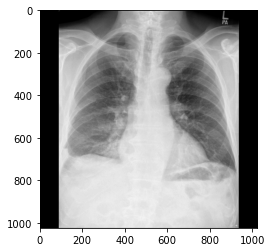

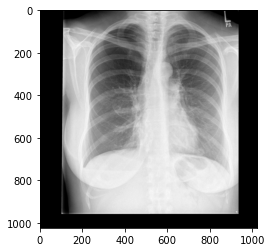

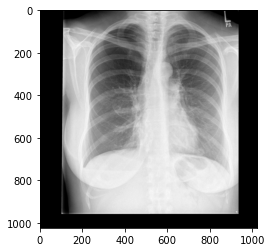

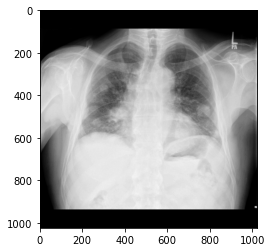

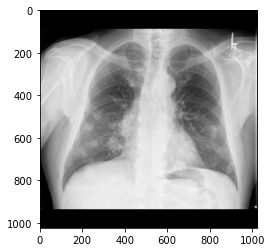

In [13]:
for img in last_five_img:
    image_path = '../../teams/dsc-180a---a14-[88137]/CANDID_PTX/' + img
#     fig_size = (10, 10)
    plt.figure()
    ds = dicom.dcmread(image_path)
    plt.imshow(ds.pixel_array, cmap = "gray")

## Split the Df into training, validating, testing set

In [37]:
unique_ids = img_with_label.groupby('SOPInstanceUID').max().reset_index()

In [38]:
positive_cases = unique_ids[unique_ids['EncodedPixels'] != '-1']

In [39]:
positive_cases

,SOPInstanceUID,EncodedPixels
0,0.0.00.400800.30.9.2.0.97200258210.26537585746...,194018 13 1004 20 1000 24 996 28 992 32 988 36...
8,0.0.07.109556.72.6.9.7.18989625890.56335195975...,574641 26 992 38 982 46 975 52 970 54 968 57 9...
11,0.0.08.203506.65.2.5.0.32924650882.36087017673...,568451 31 984 42 974 53 965 61 959 66 954 71 9...
22,0.0.15.275672.29.0.5.8.45791925255.74232884473...,594988 4 1018 11 1011 13 1009 16 1006 18 1005 ...
23,0.0.155.605300.6.541.1.9531666121.6286372288.6...,294139 1 1022 1 1022 2 1021 3 1020 4 1019 4 10...
...,...,...
19197,9.9.75.658617.70.9.5.9.31593440589.72736791796...,116469 8 1008 21 994 29 969 55 963 60 960 64 9...
19203,9.9.80.662452.12.5.4.8.556255694783923.2098816...,214691 16 990 43 973 60 955 75 941 85 930 96 9...
19214,9.9.85.254795.71.1.3.3.90113241723093.41192748...,244032 5 1012 11 1008 15 1004 19 1000 23 996 2...
19221,9.9.89.261839.37.6.8.8.25229167336.51695504316...,250005 1 1021 3 1019 6 1016 8 1014 11 1012 11 ...


In [23]:
3196 * 0.8

2556.8

### Use 2556 positive cases in the training set; so around 2556 negative cases too

In [40]:
def SOPInstanceUID_to_Mask_Path(SOPInstanceUID):
    """
    Helper function to turn SOPInstanceUID into paths with mask png files
    CHANGE USER NAME!!!
    """
    return '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_MASKS/' + SOPInstanceUID + '.png'

In [41]:
def SOPInstanceUID_to_Path(SOPInstanceUID):
    """
    Helper function to turn SOPInstanceUID into paths with mask png files
    CHANGE USER NAME!!!
    """
    return '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX/' + SOPInstanceUID

In [42]:
positive_cases_80_percent = positive_cases.iloc[:2556].reset_index(drop = True)
positive_cases_80_percent['Mask_Path'] = positive_cases_80_percent['SOPInstanceUID'].apply(SOPInstanceUID_to_Mask_Path)
positive_cases_80_percent['XRay_Path'] = positive_cases_80_percent['SOPInstanceUID'].apply(SOPInstanceUID_to_Path)
positive_cases_80_percent = positive_cases_80_percent[['Mask_Path', 'XRay_Path']]
positive_cases_80_percent

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
2551,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2552,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2553,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2554,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [43]:
negative_cases = unique_ids[unique_ids['EncodedPixels'] == '-1']
negative_cases_2556_count = negative_cases.iloc[:2556]
## CHANGE USER NAME!!!
negative_cases_2556_count['Mask_Path'] = '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_MASKS/negative_mask.png'
negative_cases_2556_count['XRay_Path'] = negative_cases_2556_count['SOPInstanceUID'].apply(SOPInstanceUID_to_Path)
negative_cases_2556_count = negative_cases_2556_count[['Mask_Path', 'XRay_Path']]
negative_cases_2556_count

/tmp/ipykernel_164/531581750.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_cases_2556_count['Mask_Path'] = '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_MASKS/negative_mask.png'
/tmp/ipykernel_164/531581750.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_cases_2556_count['XRay_Path'] = negative_cases_2556_count['SOPInstanceUID'].apply(SOPInstanceUID_to_Path)


,Mask_Path,XRay_Path
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
5,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
3046,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3047,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3048,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3049,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [44]:
train_df = pd.concat([positive_cases_80_percent, negative_cases_2556_count]).reset_index(drop = True)
train_df

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
5107,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
5108,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
5109,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
5110,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [80]:
train_df.to_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/train.csv')

### Use 320 positive cases and 320*5 negative cases as validation set

In [81]:
320 * 5

1600

In [45]:
positive_cases_val = positive_cases.iloc[2556:2556 + 320].reset_index(drop = True)
positive_cases_val['Mask_Path'] = positive_cases_val['SOPInstanceUID'].apply(SOPInstanceUID_to_Mask_Path)
positive_cases_val['XRay_Path'] = positive_cases_val['SOPInstanceUID'].apply(SOPInstanceUID_to_Path)
positive_cases_val = positive_cases_val[['Mask_Path', 'XRay_Path']]
positive_cases_val

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
315,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
316,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
317,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
318,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [46]:
negative_cases_val = negative_cases.iloc[2556:2556 + 1600]
## CHANGE USER NAME!!!
negative_cases_val['Mask_Path'] = '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_MASKS/negative_mask.png'
negative_cases_val['XRay_Path'] = negative_cases_val['SOPInstanceUID'].apply(SOPInstanceUID_to_Path)
negative_cases_val = negative_cases_val[['Mask_Path', 'XRay_Path']]
negative_cases_val

/tmp/ipykernel_164/1494773202.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_cases_val['Mask_Path'] = '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_MASKS/negative_mask.png'
/tmp/ipykernel_164/1494773202.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_cases_val['XRay_Path'] = negative_cases_val['SOPInstanceUID'].apply(SOPInstanceUID_to_Path)


,Mask_Path,XRay_Path
3051,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3052,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3053,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3054,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3055,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
4944,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4945,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4946,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4947,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [47]:
val_df = pd.concat([positive_cases_val, negative_cases_val]).reset_index(drop = True)
val_df

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
1915,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1916,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1917,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1918,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [85]:
val_df.to_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/validation.csv')

### Use 320 positive cases and 320*5 negative cases as test set

In [48]:
positive_cases_test = positive_cases.iloc[2556 + 320:].reset_index(drop = True)
positive_cases_test['Mask_Path'] = positive_cases_test['SOPInstanceUID'].apply(SOPInstanceUID_to_Mask_Path)
positive_cases_test['XRay_Path'] = positive_cases_test['SOPInstanceUID'].apply(SOPInstanceUID_to_Path)
positive_cases_test = positive_cases_test[['Mask_Path', 'XRay_Path']]
positive_cases_test

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
315,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
316,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
317,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
318,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [49]:
negative_cases_test = negative_cases.iloc[2556 + 1600: 2556 + 1600 + 1600]
## CHANGE USER NAME!!!
negative_cases_test['Mask_Path'] = '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_MASKS/negative_mask.png'
negative_cases_test['XRay_Path'] = negative_cases_test['SOPInstanceUID'].apply(SOPInstanceUID_to_Path)
negative_cases_test = negative_cases_test[['Mask_Path', 'XRay_Path']]
negative_cases_test

/tmp/ipykernel_164/1368421623.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_cases_test['Mask_Path'] = '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_MASKS/negative_mask.png'
/tmp/ipykernel_164/1368421623.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_cases_test['XRay_Path'] = negative_cases_test['SOPInstanceUID'].apply(SOPInstanceUID_to_Path)


,Mask_Path,XRay_Path
4949,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4950,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4951,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4952,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4953,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
6864,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
6865,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
6866,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
6867,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [50]:
test_df = pd.concat([positive_cases_test, negative_cases_test]).reset_index(drop = True)
test_df

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
1915,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1916,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1917,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1918,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [51]:
test_df.to_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/test.csv')

### Keep the leftover negative cases as a separate csv file

In [104]:
negative_cases_left = negative_cases.iloc[2556 + 1600 + 1600:]
negative_cases_left

,SOPInstanceUID,EncodedPixels
6870,3.6.129.270823.0.518.3.0311614976.0248083240.0...,-1
6871,3.6.130.139542.1.520.2.6904335968.1964963695.5...,-1
6872,3.6.134.159703.9.958.8.4154301319.3789742105.7...,-1
6873,3.6.14.166065.42.5.9.6.61002999863.42649822854...,-1
6874,3.6.14.384025.58.1.6.9.97925187134.69618853204...,-1
...,...,...
19232,9.9.95.839092.35.7.6.2.62219016744.47254325922...,-1
19233,9.9.958.135867.3.462.6.5426614640.7367906512.2...,-1
19234,9.9.958.486240.9031248292.38166704161539018531...,-1
19235,9.9.96.093761.90.1.2.9.09363954491.53232302786...,-1


In [106]:
negative_cases_left['Mask_Path'] = '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_MASKS/negative_mask.png'
negative_cases_left['XRay_Path'] = negative_cases_left['SOPInstanceUID'].apply(SOPInstanceUID_to_Path)
negative_cases_left = negative_cases_left[['Mask_Path', 'XRay_Path']]
negative_cases_left

/tmp/ipykernel_198/2197463569.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_cases_left['Mask_Path'] = '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_MASKS/negative_mask.png'
/tmp/ipykernel_198/2197463569.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_cases_left['XRay_Path'] = negative_cases_left['SOPInstanceUID'].apply(SOPInstanceUID_to_Path)


,Mask_Path,XRay_Path
6870,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
6871,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
6872,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
6873,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
6874,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
19232,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
19233,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
19234,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
19235,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [107]:
negative_cases_left = negative_cases_left.reset_index(drop = True)
negative_cases_left

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
10280,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
10281,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
10282,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
10283,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [108]:
negative_cases_left.to_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/unused_negative.csv')

## Shuffle validation and test set

In [3]:
val = pd.read_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/validation.csv')[['Mask_Path', 'XRay_Path']]
val

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
1915,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1916,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1917,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1918,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [5]:
val = val.sample(frac=1)
val

,Mask_Path,XRay_Path
799,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
460,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1235,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
426,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
205,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
1845,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1679,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1187,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1101,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [6]:
val = val.reset_index(drop=True)
val

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
1915,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1916,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1917,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1918,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


## Saved the shuffled validation set

In [11]:
# val.to_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/validation.csv', index=False)

##############################################################################################################################

In [13]:
test = pd.read_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/test.csv')[['Mask_Path', 'XRay_Path']]
test

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
1915,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1916,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1917,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1918,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [14]:
test = test.sample(frac=1)
test

,Mask_Path,XRay_Path
1843,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
396,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1765,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
386,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
498,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
1182,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
766,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1302,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1172,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [15]:
test = test.reset_index(drop=True)
test

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
1915,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1916,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1917,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1918,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


## Saved the shuffled test csv

In [20]:
# test.to_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/test.csv', index=False)

In [25]:
pd.read_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/test.csv')

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
1915,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1916,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1917,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1918,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


## Updated on 2/25/2023: Add a column to the csv file with the output predicted mask path

### Train

In [3]:
train = '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/train.csv'
train_df = pd.read_csv(train)
train_df

,Unnamed: 0,Mask_Path,XRay_Path
0,0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...,...
5107,5107,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
5108,5108,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
5109,5109,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
5110,5110,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [13]:
train_df.iloc[0].XRay_Path.replace("CANDID_PTX", "CANDID_PTX_PREDS") + "_predicted.png"

'/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_PREDS/0.0.00.400800.30.9.2.0.97200258210.2653758574681.8_predicted.png'

In [15]:
train_df['Intermediate_Predicted_Path'] = train_df['XRay_Path'].apply(lambda x: x.replace("CANDID_PTX", "CANDID_PTX_PREDS") + "_predicted.png")

In [19]:
train_df = train_df.iloc[:,1:]

In [22]:
train_df.iloc[2].Intermediate_Predicted_Path

'/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_PREDS/0.0.08.203506.65.2.5.0.32924650882.3608701767376.8_predicted.png'

In [33]:
#train_df.to_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/train.csv', index = False)

### Validation Set

In [25]:
val = '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/validation.csv'
val_df = pd.read_csv(val)
val_df

,Mask_Path,XRay_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...
1915,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1916,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1917,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1918,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [26]:
val_df['Intermediate_Predicted_Path'] = val_df['XRay_Path'].apply(lambda x: x.replace("CANDID_PTX", "CANDID_PTX_PREDS") + "_predicted.png")
val_df

,Mask_Path,XRay_Path,Intermediate_Predicted_Path
0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...,...
1915,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1916,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1917,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1918,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [30]:
val_df.iloc[0].Intermediate_Predicted_Path

'/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_PREDS/1.9.20.392893.71.2.2.7.48335132448.7624003141983.1_predicted.png'

In [31]:
#val_df.to_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/validation.csv', index = False)

### Test set

In [52]:
test = '/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/test.csv'
test_df = pd.read_csv(test)
test_df

,Unnamed: 0,Mask_Path,XRay_Path
0,0,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1,1,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
2,2,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
3,3,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
4,4,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
...,...,...,...
1915,1915,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1916,1916,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1917,1917,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...
1918,1918,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...,/home/anw008/teams/dsc-180a---a14-[88137]/CAND...


In [54]:
test_df['Intermediate_Predicted_Path'] = test_df['XRay_Path'].apply(lambda x: x.replace("CANDID_PTX", "CANDID_PTX_PREDS") + "_predicted.png")
test_df = test_df.iloc[:,1:]

In [56]:
test_df.iloc[0].Intermediate_Predicted_Path

'/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_PREDS/9.0.01.088363.13.1.2.8.68704432684.2413975829325.0_predicted.png'

In [57]:
#test_df.to_csv('/home/anw008/teams/dsc-180a---a14-[88137]/CANDID_PTX_csv/test.csv', index = False)